# Point estimates and sampling variability

---

#### Summary videos

- [Foundations for inference: point estimates and sampling variability](https://youtu.be/oLW_uzkPZGA?si=dgJpuib4fNeKVtlS) (19 minutes)
- [But what is the Central Limit Theorem?](https://youtu.be/zeJD6dqJ5lo?si=a7Vs3X1X2k-JsZXu) (31 minutes)

#### Walkthrough videos

- [Point estimates, error, and variability](https://drive.google.com/file/d/1mXV-GwigBkD66eFl35XR0bpmDexll4WD/view?usp=sharing) (8 minutes)
- [Sampling distributions](https://drive.google.com/file/d/1HdhEmh1xHbaIrDMAV-3ji45a3oiElhFF/view?usp=sharing) (9 minutes)
- [The central limit theorem](https://drive.google.com/file/d/1TPvQJZHkkc9TvVNv6o8P1DCZrBgn4Uuc/view?usp=sharing) (15 minutes)
- [Additional remarks](https://drive.google.com/file/d/10U4dszkmhHpnOag--Ejvng5LpA-7hmRu/view?usp=sharing) (7 minutes)

---

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from plotnine import *

pew = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/pew_energy_2018.csv')

In [ ]:
pew.shape

The `pew` data set contains information on 2541 Americans surveyed about their support for increases in various sources of energy by Pew Research.

In [ ]:
pew.head()

### Exercise

What proportion of people surveyed support increasing the use of solar panel farms?

In [ ]:
sum(pew['solar_panel_farms'] == 'favor_increase') / 2541

## Point estimates, error, and variability

The proportion we computed above from the sample of Americans in the `pew` data set is called a **point estimate** (or **sample statistic**), which we might denote $\hat{p}$.

### Questions
* Do you expect the *actual* proportion of Americans in support of increasing the use of solar panel farms to *exactly* equal to $\hat{p}$?
* If we took a different sample of Americans, would you expect the point estimate to be *exactly* equal to the original sample's point estimate?

The true proportion of all Americans in support of increasing the use of solar panel farms is called the **population paramater**, which we could call $p$.

We hope to use $\hat{p}$ to *approximate* $p$.
* The difference between the point estimate and the popluation parameter is called the **error**.
* **Sampling uncertainty** or **sampling variability** desrcibes how much a point estimate will tend to vary from one sample to the next.
  * We can use the **sample size** to help use quantify this uncertainty.
* **Bias** refers to a systematic tendency to over/under-estimate the population parameter from your samples.
  * Recall our discussion on bias in Chapter 1!

## Sampling distributions

A very large sample suggests that the true value of the population parameter is $p = 0.88$, which is to say

> 88% of Americans are in favor of increasing the use of solar panel farms as a source of energy.

### Exercise
Determine the error of the point estimate from our `pew` sample to the true value of the population parameter.

If we take a different sample, how much should we expect the point estimate to vary in reference to $p$? It would be difficult and time consuming to conduct this particular survey repeatedly. Luckily, we can simulate the situation with Python!

In [ ]:
# Simulate a sample survey of 1000 Americans. Run this a few times to see
# p_hat change with different samples!

sample_responses = np.random.choice(['favor_increase', 'no_increase'], size = 1000, p =[0.88, 0.12])

p_hat = sum(sample_responses == 'favor_increase')/1000

print(p_hat)

We can now look at the point estimates from 10,000 simulated samples to investigate the **sampling distribution** for $\hat{p}$.

In [ ]:
# Simulate 10,000 sample surveys of 1000 Americans

sample_distribution = []
for i in range(10000):
  sample_responses = np.random.choice(['favor_increase', 'no_increase'], size = 1000, p =[0.88, 0.12])
  p_hat = sum(sample_responses == 'favor_increase')/1000
  sample_distribution.append(p_hat)

(
    ggplot(pd.DataFrame(sample_distribution, columns = ['p_hat'])) +
    aes(x = 'p_hat') +
    geom_histogram(bins = 20)
)

In [ ]:
pd.DataFrame(sample_distribution).describe()

### Exercises
* Describe the center, spread, and shape of this sampling distribution.

* Identify the mean and standard deviation.
  * Note that, in the case of a sampling distribution, the standard deviation is called the **standard error**.


* Does it look like a distribution that you recognize?

## The Central Limit Theorem (CLT)

The fact that sampling distributions tend to follow a normal distribution is a consequence of the **Central Limit Theorem**, as seen on page 172 of the textbook.

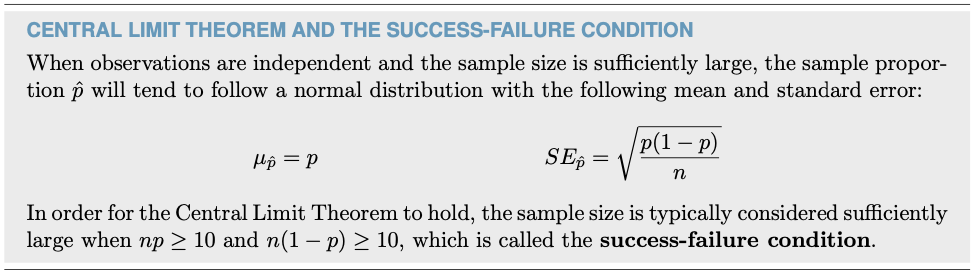

Note that, in practice, the true population parameter $p$ is not known. It is common to use a particular sample's point estimate $\hat{p}$ in place of $p$ for computing the standard error of the sampling distribution and to check the success-failure conditions.

### Exercise
Given the formula for standard error of a sampling distribution above, explain why a smaller sample size would tend to produce a less reliable point estimate.

### Exercise

* Verify that our `pew` research data satisfies the conditions of the Central Limit Theorem.
* Use the Central Limit Theorem to find the theorectical mean and standard error for the sampling distribution above. Recall, in this case we happen to know that $p = 0.88$.
  * Compare these to the simulated values.
* Use https://www.geogebra.org/classic#probability to visualize the sampling distribution above.
* What is the probability that a given sample proportion is between 86% and 90%?
* What is the probability that the sample proportion is less than or equal to 90%?
* What is the probability that the sample proportion is greater than or equal to 90%?

## Additional remarks

* The Central Limit Theorem implies (under certain conditions) that the sampling distribution will be normal *regardless of whether or not the original data from a population are normal!*
* If the conditions of the Central Limit Theorem are *not* met, the sampling distribution *need not be* normal (cf. pages 175–177 of the textbook).
* While we discussed sampling distributions for a proportion here, these ideas extend to other numerical summaries of data, such as the sample mean.

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.